# POS/Cash Balance Exploratory Data Analysis

This notebook explores the monthly records of previous point-of-sale and cash loans. It examines applicant coverage, missing values, contract status, installment progress and overdue-payment behaviour. The findings will be used to guide the cleaning and feature-engineering steps.

## Import libraries


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")

BLUE = "#2E6DB4"
ORANGE = "#E67E22"

print("Libraries imported successfully.")


Libraries imported successfully.


## Set file paths


In [5]:
pos_path = "data/raw/POS_CASH_balance.csv"
application_path = "data/raw/application_train.csv"


## Load the data


In [7]:
pos_cash = pd.read_csv(pos_path)
application_target = pd.read_csv(application_path, usecols=["SK_ID_CURR", "TARGET"])

print("POS/Cash rows:", pos_cash.shape[0])
print("POS/Cash columns:", pos_cash.shape[1])
print("Labelled applicants:", len(application_target))
pos_cash.head()


POS/Cash rows: 10001358
POS/Cash columns: 8
Labelled applicants: 307511


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


## Structure, monthly keys, and duplicates


In [9]:
loan_month_key = ["SK_ID_PREV", "MONTHS_BALANCE"]

print("Exact duplicate rows:", pos_cash.duplicated().sum())
print("Duplicate loan-month keys:", pos_cash.duplicated(loan_month_key).sum())
print("Missing SK_ID_PREV:", pos_cash["SK_ID_PREV"].isna().sum())
print("Missing SK_ID_CURR:", pos_cash["SK_ID_CURR"].isna().sum())
print("Unique applicants in complete file:", pos_cash["SK_ID_CURR"].nunique())
print("Unique previous POS/Cash loans:", pos_cash["SK_ID_PREV"].nunique())
print("Month range:", pos_cash["MONTHS_BALANCE"].min(), "to", pos_cash["MONTHS_BALANCE"].max())


Exact duplicate rows: 0
Duplicate loan-month keys: 0
Missing SK_ID_PREV: 0
Missing SK_ID_CURR: 0
Unique applicants in complete file: 337252
Unique previous POS/Cash loans: 936325
Month range: -96 to -1


## Labelled-applicant coverage

In [11]:
labelled_applicant_ids = set(application_target["SK_ID_CURR"])
pos_applicant_ids = set(pos_cash["SK_ID_CURR"])

matched_labelled_ids = labelled_applicant_ids.intersection(pos_applicant_ids)
labelled_ids_without_pos = labelled_applicant_ids.difference(pos_applicant_ids)
pos_ids_not_in_application = pos_applicant_ids.difference(labelled_applicant_ids)

coverage_percent = len(matched_labelled_ids) / len(labelled_applicant_ids) * 100

print("Labelled applicants with POS/Cash history:", len(matched_labelled_ids))
print("Applicant coverage:", round(coverage_percent, 2), "%")
print("Labelled applicants without POS/Cash history:", len(labelled_ids_without_pos))
print("POS/Cash applicant IDs not found in application data:", len(pos_ids_not_in_application))

Labelled applicants with POS/Cash history: 289444
Applicant coverage: 94.12 %
Labelled applicants without POS/Cash history: 18067
POS/Cash applicant IDs not found in application data: 47808


In [12]:
coverage_table = application_target.copy()
coverage_table["HAS_POS_HISTORY"] = coverage_table["SK_ID_CURR"].isin(pos_applicant_ids)

coverage_default_summary = coverage_table.groupby("HAS_POS_HISTORY")["TARGET"].agg(["count", "mean"])
coverage_default_summary["default_rate_percent"] = coverage_default_summary["mean"] * 100
coverage_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
HAS_POS_HISTORY,,
False,18067,6.66
True,289444,8.16


POS/Cash history is available for 94.12% of labelled applicants. Applicants with this history default a bit more often than applicants without it, so this could be a useful signal for the model.


## Missing-value analysis


In [15]:
missing_summary = pd.DataFrame({
    "missing_count": pos_cash.isna().sum(),
    "missing_percent": (pos_cash.isna().mean() * 100).round(4),
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary = missing_summary.sort_values("missing_percent", ascending=False)

print("Columns containing missing values:", len(missing_summary))
missing_summary


Columns containing missing values: 2


,missing_count,missing_percent
CNT_INSTALMENT_FUTURE,26087,0.2608
CNT_INSTALMENT,26071,0.2607


These missing values are for the total number of installments and the number of installments remaining. Both columns will be kept, and the missing repayment schedules will be looked at more closely during cleaning.


## Contract status and monthly history


In [18]:
status_table = pos_cash["NAME_CONTRACT_STATUS"].value_counts(dropna=False).to_frame("count")
status_table["percent"] = status_table["count"] / len(pos_cash) * 100
status_table.round(3)


,count,percent
NAME_CONTRACT_STATUS,,
Active,9151119,91.499
Completed,744883,7.448
Signed,87260,0.872
Demand,7065,0.071
Returned to the store,5461,0.055
Approved,4917,0.049
Amortized debt,636,0.006
Canceled,15,0.000
XNA,2,0.000


In [19]:
loan_history = pos_cash.groupby("SK_ID_PREV")["MONTHS_BALANCE"].agg(["count", "min", "max"])
loan_history.columns = ["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH"]
loan_history["EXPECTED_MONTH_COUNT"] = loan_history["MOST_RECENT_MONTH"] - loan_history["OLDEST_MONTH"] + 1
loan_history["MISSING_MONTH_COUNT"] = loan_history["EXPECTED_MONTH_COUNT"] - loan_history["MONTH_COUNT"]

print("Loans with gaps in monthly history:", (loan_history["MISSING_MONTH_COUNT"] > 0).sum())
loan_history[["MONTH_COUNT", "OLDEST_MONTH", "MOST_RECENT_MONTH", "MISSING_MONTH_COUNT"]].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)


Loans with gaps in monthly history: 1950


,MONTH_COUNT,OLDEST_MONTH,MOST_RECENT_MONTH,MISSING_MONTH_COUNT
count,936325.000000,936325.000000,936325.000000,936325.000000
mean,10.681503,-39.784147,-30.095220,0.007424
std,6.956280,27.549457,27.521187,0.241011
min,1.000000,-96.000000,-96.000000,0.000000
25%,7.000000,-60.000000,-50.000000,0.000000
50%,10.000000,-32.000000,-22.000000,0.000000
75%,13.000000,-17.000000,-6.000000,0.000000
90%,19.000000,-9.000000,-1.000000,0.000000
95%,24.000000,-6.000000,-1.000000,0.000000
99%,33.000000,-2.000000,-1.000000,0.000000


Most monthly records belong to active contracts. A few contract statuses are very rare and can be grouped together during cleaning. Very few loans have gaps in their monthly history, so this is not a major issue.


## Installment counts and domain checks


In [22]:
numeric_summary = pos_cash[["CNT_INSTALMENT", "CNT_INSTALMENT_FUTURE", "SK_DPD", "SK_DPD_DEF"]].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
).T
numeric_summary[["count", "mean", "min", "1%", "50%", "99%", "max"]]


,count,mean,min,1%,50%,99%,max
CNT_INSTALMENT,9975287.0,17.089650,1.0,4.0,12.0,60.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,10.483840,0.0,0.0,7.0,53.0,85.0
SK_DPD,10001358.0,11.606928,0.0,0.0,0.0,235.0,4231.0
SK_DPD_DEF,10001358.0,0.654468,0.0,0.0,0.0,1.0,3595.0


These checks look for values that do not follow the expected structure of the data, for example negative installment counts or overdue days, and future installments that are higher than total installments.


In [24]:
domain_checks = pd.DataFrame({
    "check": [
        "MONTHS_BALANCE is positive",
        "CNT_INSTALMENT is negative",
        "CNT_INSTALMENT_FUTURE is negative",
        "Future installments exceed total installments",
        "SK_DPD is negative",
        "SK_DPD_DEF is negative",
        "SK_ID_CURR is missing",
        "SK_ID_PREV is missing"
    ],
    "rows_affected": [
        (pos_cash["MONTHS_BALANCE"] > 0).sum(),
        (pos_cash["CNT_INSTALMENT"] < 0).sum(),
        (pos_cash["CNT_INSTALMENT_FUTURE"] < 0).sum(),
        (pos_cash["CNT_INSTALMENT_FUTURE"] > pos_cash["CNT_INSTALMENT"]).sum(),
        (pos_cash["SK_DPD"] < 0).sum(),
        (pos_cash["SK_DPD_DEF"] < 0).sum(),
        pos_cash["SK_ID_CURR"].isna().sum(),
        pos_cash["SK_ID_PREV"].isna().sum(),
    ]
})
domain_checks


,check,rows_affected
0,MONTHS_BALANCE is positive,0
1,CNT_INSTALMENT is negative,0
2,CNT_INSTALMENT_FUTURE is negative,0
3,Future installments exceed total installments,7420
4,SK_DPD is negative,0
5,SK_DPD_DEF is negative,0
6,SK_ID_CURR is missing,0
7,SK_ID_PREV is missing,0


Nothing major was found, apart from some records that show more future installments than total installments. These will be kept and flagged during cleaning instead of being removed.


## Create monthly behaviour measures

In [27]:
valid_installment_count = (
    (pos_cash["CNT_INSTALMENT"] > 0)
    & (pos_cash["CNT_INSTALMENT_FUTURE"] >= 0)
    & (pos_cash["CNT_INSTALMENT_FUTURE"] <= pos_cash["CNT_INSTALMENT"])
)
pos_cash["INSTALLMENT_COMPLETION_RATE"] = np.nan
pos_cash.loc[valid_installment_count, "INSTALLMENT_COMPLETION_RATE"] = (
    1 - pos_cash.loc[valid_installment_count, "CNT_INSTALMENT_FUTURE"]
    / pos_cash.loc[valid_installment_count, "CNT_INSTALMENT"]
)
pos_cash["IS_DELINQUENT"] = (pos_cash["SK_DPD_DEF"] > 0).astype(int)
pos_cash["IS_SEVERE_DELINQUENCY"] = (pos_cash["SK_DPD_DEF"] > 30).astype(int)
pos_cash["IS_COMPLETED_STATUS"] = (pos_cash["NAME_CONTRACT_STATUS"] == "Completed").astype(int)
# This table ends at month -1, so months -12 through -1 form 12 months.
pos_cash["IS_RECENT_12_MONTHS"] = (pos_cash["MONTHS_BALANCE"] >= -12).astype(int)
pos_cash["RECENT_DELINQUENCY"] = (
    (pos_cash["IS_DELINQUENT"] == 1) & (pos_cash["IS_RECENT_12_MONTHS"] == 1)
).astype(int)

pos_cash["INSTALLMENT_COMPLETION_RATE"].describe(percentiles=[0.01, 0.50, 0.95, 0.99])


count    9.967754e+06
mean     4.537224e-01
std      3.290447e-01
min      0.000000e+00
1%       0.000000e+00
50%      4.166667e-01
95%      1.000000e+00
99%      1.000000e+00
max      1.000000e+00
Name: INSTALLMENT_COMPLETION_RATE, dtype: float64

The installment completion rate shows how much of the planned repayment schedule has been completed, from 0 (not started) to 1 (fully completed). A few more indicators are also created here for overdue months, serious overdue cases, and recent overdue activity.


## Behaviour distributions

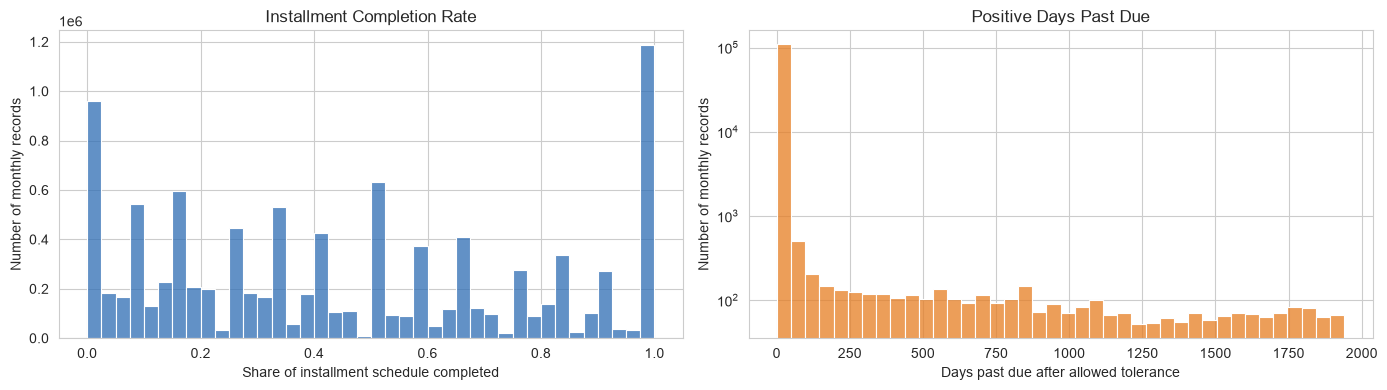

In [30]:
positive_dpd = pos_cash.loc[pos_cash["SK_DPD_DEF"] > 0, "SK_DPD_DEF"]
dpd_limit = positive_dpd.quantile(0.99)
valid_completion = pos_cash["INSTALLMENT_COMPLETION_RATE"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(valid_completion, bins=40, ax=axes[0], color=BLUE)
sns.histplot(positive_dpd[positive_dpd <= dpd_limit], bins=40, ax=axes[1], color=ORANGE)
axes[0].set_title("Installment Completion Rate")
axes[1].set_title("Positive Days Past Due")

axes[0].set_xlabel("Share of installment schedule completed")
axes[1].set_xlabel("Days past due after allowed tolerance")

axes[0].set_ylabel("Number of monthly records")
axes[1].set_ylabel("Number of monthly records")
axes[1].set_yscale("log") 

plt.tight_layout()
plt.show()


The completion-rate chart shows loans at different stages of their repayment schedule, some just started, others close to finished. Most overdue records only have a few overdue days, with a small number much higher. The chart is capped at the 99th percentile to make the main pattern easier to see.


## Applicant-level behaviour

In [33]:
pos_labelled = pos_cash[pos_cash["SK_ID_CURR"].isin(labelled_applicant_ids)].copy()

applicant_pos = pos_labelled.groupby("SK_ID_CURR").agg(
    POS_MONTH_COUNT=("MONTHS_BALANCE", "count"),
    POS_LOAN_COUNT=("SK_ID_PREV", "nunique"),
    POS_AVERAGE_TOTAL_INSTALLMENTS=("CNT_INSTALMENT", "mean"),
    POS_AVERAGE_REMAINING_INSTALLMENTS=("CNT_INSTALMENT_FUTURE", "mean"),
    POS_MEDIAN_COMPLETION_RATE=("INSTALLMENT_COMPLETION_RATE", "median"),
    POS_COMPLETED_STATUS_COUNT=("IS_COMPLETED_STATUS", "sum"),
    POS_DELINQUENT_MONTH_COUNT=("IS_DELINQUENT", "sum"),
    POS_DELINQUENT_MONTH_RATE=("IS_DELINQUENT", "mean"),
    POS_SEVERE_MONTH_COUNT=("IS_SEVERE_DELINQUENCY", "sum"),
    POS_MAX_DPD_DEF=("SK_DPD_DEF", "max"),
    POS_RECENT_OBSERVED_MONTHS=("IS_RECENT_12_MONTHS", "sum"),
    POS_RECENT_DELINQUENT_COUNT=("RECENT_DELINQUENCY", "sum"),
).reset_index()

applicant_pos["POS_RECENT_DELINQUENT_RATE"] = np.where(
    applicant_pos["POS_RECENT_OBSERVED_MONTHS"] > 0,
    applicant_pos["POS_RECENT_DELINQUENT_COUNT"] / applicant_pos["POS_RECENT_OBSERVED_MONTHS"],
    np.nan,
)

print("Labelled applicants with POS/Cash features:", len(applicant_pos))
applicant_pos.head()


Labelled applicants with POS/Cash features: 289444


,SK_ID_CURR,POS_MONTH_COUNT,POS_LOAN_COUNT,POS_AVERAGE_TOTAL_INSTALLMENTS,POS_AVERAGE_REMAINING_INSTALLMENTS,POS_MEDIAN_COMPLETION_RATE,POS_COMPLETED_STATUS_COUNT,POS_DELINQUENT_MONTH_COUNT,POS_DELINQUENT_MONTH_RATE,POS_SEVERE_MONTH_COUNT,POS_MAX_DPD_DEF,POS_RECENT_OBSERVED_MONTHS,POS_RECENT_DELINQUENT_COUNT,POS_RECENT_DELINQUENT_RATE
0,100002,19,1,24.000000,15.000000,0.375000,0,0,0.0,0,0,12,0,0.0
1,100003,28,3,10.107143,5.785714,0.416667,2,0,0.0,0,0,0,0,NaN
2,100004,4,1,3.750000,2.250000,0.375000,1,0,0.0,0,0,0,0,NaN
3,100006,21,3,12.000000,8.650000,0.333333,2,0,0.0,0,0,13,0,0.0
4,100007,66,5,15.333333,8.969697,0.414216,3,0,0.0,0,0,14,0,0.0


In [34]:
applicant_pos_target = application_target.merge(applicant_pos, on="SK_ID_CURR", how="left")
feature_columns = [column for column in applicant_pos.columns if column != "SK_ID_CURR"]
feature_correlations = applicant_pos_target[feature_columns + ["TARGET"]].corr()["TARGET"].drop("TARGET")
feature_correlations.sort_values().to_frame("correlation_with_target").round(4)


,correlation_with_target
POS_LOAN_COUNT,-0.0405
POS_MONTH_COUNT,-0.0356
POS_MEDIAN_COMPLETION_RATE,-0.0271
POS_COMPLETED_STATUS_COUNT,-0.0195
POS_RECENT_OBSERVED_MONTHS,-0.0141
POS_SEVERE_MONTH_COUNT,0.0064
POS_MAX_DPD_DEF,0.0096
POS_AVERAGE_TOTAL_INSTALLMENTS,0.0181
POS_DELINQUENT_MONTH_COUNT,0.0264
POS_AVERAGE_REMAINING_INSTALLMENTS,0.0278


These correlations are all fairly small on their own, since default risk depends on many factors together. Recent and overall delinquency rates, along with remaining installments, have a positive relationship with default. Loan count, number of observed months, and installment completion rate have a negative relationship. These are worth keeping for feature engineering.


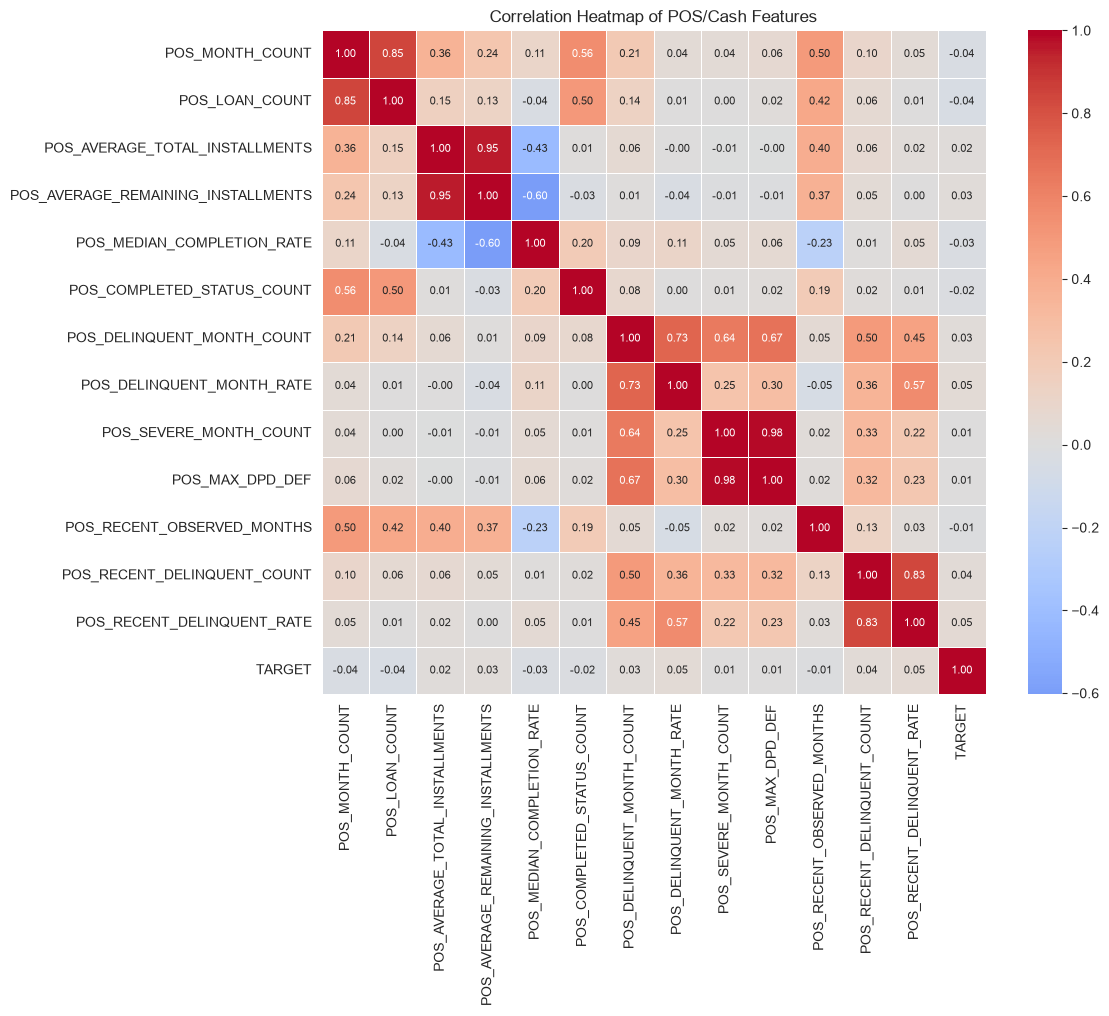

In [36]:
correlation_columns = feature_columns + ["TARGET"]
correlation_matrix = applicant_pos_target[correlation_columns].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap of POS/Cash Features")
plt.tight_layout()
plt.show()

The heatmap shows the same relationships as the correlation table, but visually. Red means a positive relationship with default, blue means negative. Some features are strongly related to each other because they describe similar behaviour, for example delinquent-month count and delinquent-month rate.


In [38]:
delinquent_count = applicant_pos_target["POS_DELINQUENT_MONTH_COUNT"]
applicant_pos_target["POS_DELINQUENCY_GROUP"] = np.select(
    [delinquent_count.isna(), delinquent_count > 0],
    ["No POS/Cash history", "Has delinquent POS/Cash months"],
    default="No delinquent POS/Cash months",
)

delinquency_default_summary = applicant_pos_target.groupby("POS_DELINQUENCY_GROUP")["TARGET"].agg(["count", "mean"])
delinquency_default_summary["default_rate_percent"] = delinquency_default_summary["mean"] * 100
delinquency_default_summary.drop(columns="mean").round(2)


,count,default_rate_percent
POS_DELINQUENCY_GROUP,,
Has delinquent POS/Cash months,39890,10.80
No POS/Cash history,18067,6.66
No delinquent POS/Cash months,249554,7.74


Applicants with delinquent POS/Cash months default more often than applicants with POS/Cash history but no delinquent months. This suggests overdue POS/Cash payments could be useful for the final model.


## Main findings and next step

The POS/Cash balance table contains more than 10 million monthly records for 337,252 applicants and 936,325 previous loans. No duplicate loan-month records or missing identifiers were found.

POS/Cash history is available for about 94% of labelled applicants. Only two columns have missing values, and their missing rates are below 0.3%. Most contracts are active, and gaps in monthly histories are uncommon.

The main data-quality issue is that some records show more future installments than total installments. A few contract statuses are also very rare. These will be flagged or grouped during cleaning instead of being removed without review.

Installment progress, remaining installments, and overdue-payment behaviour all look like they could be useful for default prediction. The cleaning stage will prepare these records before the applicant-level features are created.
